In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

In [2]:
archivo = pd.read_csv('hojas.csv', sep = ';', decimal=',')
clases = archivo['clase'].values
vert = archivo['n_vertices'].values
anch = archivo['ancho'].values
larg = archivo['largo'].values
ratio = larg/anch
clase_1 = clases == 0
print(ratio [clase_1])

[4.66666667 2.5        2.         1.66666667 3.         1.76470588
 2.16666667 1.43333333 2.5        1.66666667 2.8        3.18181818
 4.         2.93333333 3.14285714 1.75       1.66666667 3.07142857]


In [3]:
#Modelo
def modelo(vert, ratio):
    if vert == 1:
        if ratio < 1.7:
            return '1'
        else:
            return '0'
    elif vert > 1:
        if vert < 7 and vert > 1:
            return ' 2'
        else:
            return '3'


In [4]:
precision = 0

for i in range(len(clases)):
    valor_real = clases[i]
    valor_predicho = modelo(vert[i], ratio[i])
    
    print(f'Hoja {i+1}: Clase Real = {valor_real}, Clase Predicha = {valor_predicho}')
    if int(valor_real) == int(valor_predicho):
        precision += 1

precision /= len(clases)
print(f'Precisión del modelo: {precision:.2f}')

Hoja 1: Clase Real = 0, Clase Predicha = 0
Hoja 2: Clase Real = 0, Clase Predicha = 0
Hoja 3: Clase Real = 2, Clase Predicha =  2
Hoja 4: Clase Real = 0, Clase Predicha = 0
Hoja 5: Clase Real = 0, Clase Predicha = 1
Hoja 6: Clase Real = 0, Clase Predicha = 0
Hoja 7: Clase Real = 3, Clase Predicha = 3
Hoja 8: Clase Real = 1, Clase Predicha = 1
Hoja 9: Clase Real = 1, Clase Predicha = 1
Hoja 10: Clase Real = 0, Clase Predicha = 0
Hoja 11: Clase Real = 0, Clase Predicha = 0
Hoja 12: Clase Real = 1, Clase Predicha = 0
Hoja 13: Clase Real = 0, Clase Predicha = 1
Hoja 14: Clase Real = 0, Clase Predicha = 0
Hoja 15: Clase Real = 0, Clase Predicha = 1
Hoja 16: Clase Real = 2, Clase Predicha =  2
Hoja 17: Clase Real = 2, Clase Predicha =  2
Hoja 18: Clase Real = 0, Clase Predicha = 0
Hoja 19: Clase Real = 0, Clase Predicha = 0
Hoja 20: Clase Real = 2, Clase Predicha = 3
Hoja 21: Clase Real = 1, Clase Predicha = 1
Hoja 22: Clase Real = 0, Clase Predicha = 0
Hoja 23: Clase Real = 0, Clase Predich

Importancia de las características: n_vertices = 0.78, ratio = 0.22


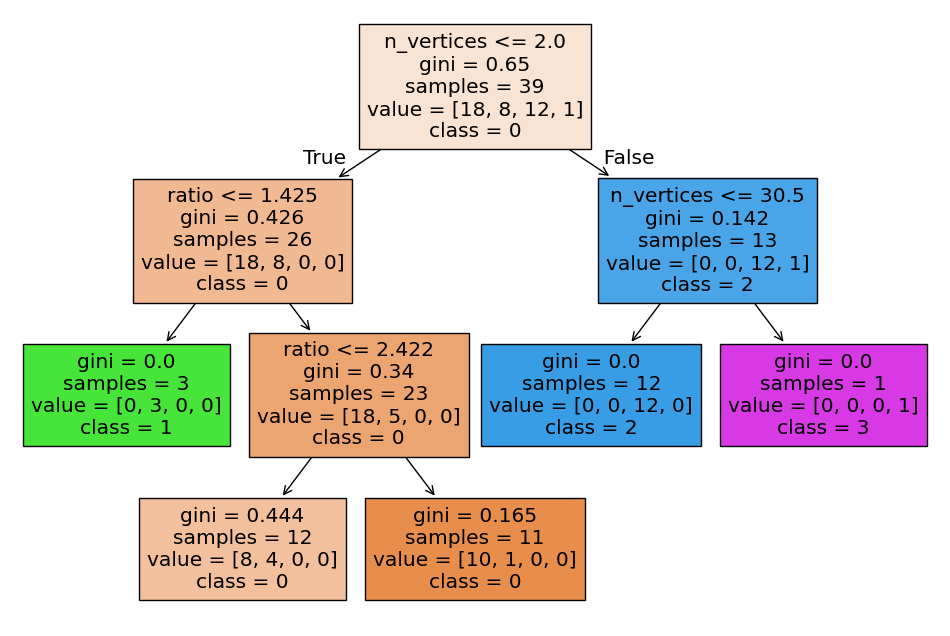

In [5]:
#Arbol de decisión
X = np.column_stack((vert, ratio))
y = clases
arbol = DecisionTreeClassifier(max_depth=3)
arbol.fit(X, y)
pesos = arbol.feature_importances_
print(f'Importancia de las características: n_vertices = {pesos[0]:.2f}, ratio = {pesos[1]:.2f}')
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))
plot_tree(arbol, feature_names=['n_vertices', 'ratio'], class_names=['0', '1', '2', '3'], filled=True)
plt.savefig('arbol_decision.png')
plt.show()

In [6]:
#Validation and Evaluation
val = pd.read_csv('Val.csv', sep = ';', decimal=',')
val_class = val['Clase'].values
val_vert = val['Vertices'].values
val_anch = val['Ancho'].values
val_larg = val['Largo'].values
ratio_val = val_larg/val_anch
X_val = np.column_stack((val_vert, ratio_val))
test = pd.read_csv('Test.csv', sep = ';', decimal=',')
test_class = test['clase'].values
test_vert = test['n_vertices'].values
test_anch = test['ancho'].values
test_larg = test['largo'].values
ratio_test = test_larg/test_anch
X_test = np.column_stack((test_vert, ratio_test))

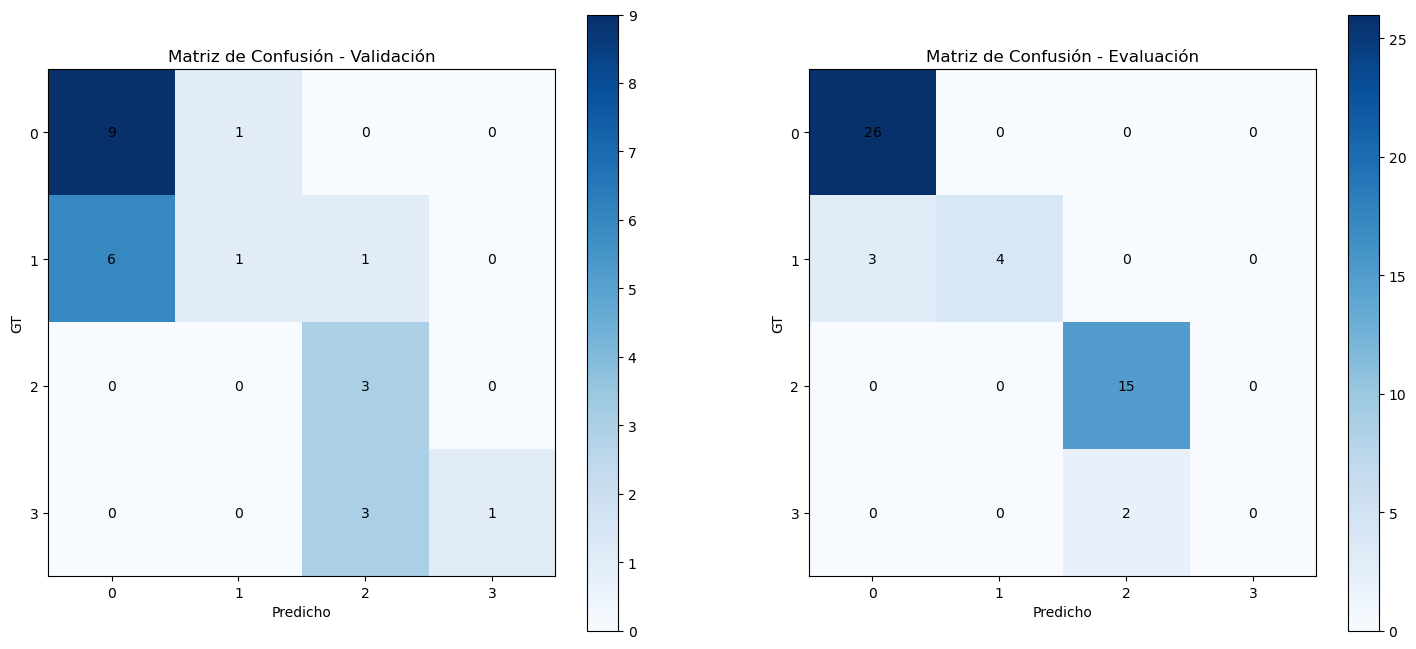

In [20]:
#Random Forest
vals = arbol.predict(X_val)
tests = arbol.predict(X_test)
labels = sorted(np.unique(np.concatenate([val_class, vals])))
confusion_val = pd.crosstab(
    pd.Categorical(val_class, categories=labels),
    pd.Categorical(vals, categories=labels),
    rownames=['Actual'],
    colnames=['Predicho'],
    dropna=False
)
confusion_test = pd.crosstab(
    pd.Categorical(test_class, categories=labels),
    pd.Categorical(tests, categories=labels),
    rownames=['Actual'],
    colnames=['Predicho'],
    dropna=False
)
plt.figure(figsize=(18, 8))
plt.subplot(1, 2, 1)
plt.title('Matriz de Confusión - Validación')
plt.imshow(confusion_val, cmap='Blues')
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)
plt.xlabel('Predicho')
plt.ylabel('GT')
#colocar numeros en la matriz
for i in range(confusion_val.shape[0]):
    for j in range(confusion_val.shape[1]):
        plt.text(j, i, confusion_val.iloc[i, j], ha='center', va='center', color='black')
plt.colorbar()
plt.subplot(1, 2, 2)
plt.title('Matriz de Confusión - Evaluación')
plt.imshow(confusion_test, cmap='Blues')
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)
plt.xlabel('Predicho')
plt.ylabel('GT')
#colocar numeros en la matriz
for i in range(confusion_test.shape[0]):
    for j in range(confusion_test.shape[1]):
        plt.text(j, i, confusion_test.iloc[i, j], ha='center', va='center', color='black')
plt.colorbar()
#plt.tight_layout()
plt.savefig('matrices_confusion.png')

In [8]:
#precision recall and f1
from sklearn.metrics import classification_report
print("Reporte de clasificación - Validación:")
print(classification_report(val_class, vals))
print("Reporte de clasificación - Prueba:")
print(classification_report(test_class, tests))

Reporte de clasificación - Validación:
              precision    recall  f1-score   support

           0       0.60      0.90      0.72        10
           1       0.50      0.12      0.20         8
           2       0.43      1.00      0.60         3
           3       1.00      0.25      0.40         4

    accuracy                           0.56        25
   macro avg       0.63      0.57      0.48        25
weighted avg       0.61      0.56      0.49        25

Reporte de clasificación - Prueba:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        26
           1       1.00      0.57      0.73         7
           2       0.88      1.00      0.94        15
           3       0.00      0.00      0.00         2

    accuracy                           0.90        50
   macro avg       0.69      0.64      0.65        50
weighted avg       0.87      0.90      0.87        50



c:\Users\simon\anaconda3\envs\astro_ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\simon\anaconda3\envs\astro_ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\simon\anaconda3\envs\astro_ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [9]:
#Cross-validation
from sklearn.model_selection import cross_validate
X_train = np.column_stack((vert, ratio))
y_train = clases

scores_cv = cross_validate(
    DecisionTreeClassifier(max_depth=5), 
    X_train, y_train, 
    cv=5,
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
)

print(f"Dataset: hojas.csv ({len(clases)} muestras)")
print(f"Accuracy:  {scores_cv['test_accuracy'].mean():.3f} (+/- {scores_cv['test_accuracy'].std():.3f})")
print(f"Precision: {scores_cv['test_precision_macro'].mean():.3f}")
print(f"Recall:    {scores_cv['test_recall_macro'].mean():.3f}")
print(f"F1:        {scores_cv['test_f1_macro'].mean():.3f}")


Dataset: hojas.csv (39 muestras)
Accuracy:  0.739 (+/- 0.148)
Precision: 0.601
Recall:    0.633
F1:        0.600


c:\Users\simon\anaconda3\envs\astro_ml\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\simon\anaconda3\envs\astro_ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\simon\anaconda3\envs\astro_ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\simon\anaconda3\envs\astro_ml\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWar